# Grain-Boundary Structure → Thermal Boundary Resistance

Analysis and ML pipeline built on the dataset produced by
`ml/format_cleaned_data.py` (`dataset.csv`). One row per grain boundary:

- **Geometry / identity** — `gb_label`, `sigma`, `gb_character` (twist / tilt /
  mixed), `tilt_type`, `misorientation_deg`, `inclination_deg`
- **Disorder descriptors** (atom subsets `full` and `gb10`) —
  `{subset}_sigma_theta`, `_sigma_l`, `_H_phi`, `_A_RDF`, `_rho`
- **GB energy** — `gamma_j_m2`, `gamma_ev_ang2`, …
- **rNEMD targets** — `R_K_mean` (Kapitza resistance ≡ thermal boundary
  resistance, TBR), `kappa_mean`, …

> Twist/tilt character and the misorientation/inclination angles are computed
> upstream by `utils/gb_geometry.py` and read straight from the CSV — this
> notebook never re-derives them. SOAP / Kernel-PCA / UMAP from the old pipeline
> have been removed (those columns no longer exist).

In [1]:
import os

# ---- Resource caps (set BEFORE importing numpy / sklearn) ----------------
# Keep BLAS/OpenMP single-threaded so their thread pools don't multiply
# against joblib workers. On a shared login node an uncapped
# threads x workers explosion can exhaust memory and get the kernel
# (and the VS Code server) OOM-killed.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- Configuration -------------------------------------------------------
DATASET = "/projects/p33174/PSED_results/full/dataset.csv"
SUBSET  = "gb10"          # atom subset used for the "measures of disorder"
TARGET  = "R_K_mean"      # thermal boundary resistance (Kapitza resistance)
RANDOM_STATE = 42

# TBR is stored in m^2 K / W (~1e-9). Rescale into m^2 K / GW so the target
# and its errors are O(1). TARGET_LABEL is reused on every axis showing R_K.
TBR_SCALE    = 1e9
TBR_UNIT     = r"m$^2$K/GW"
TARGET_LABEL = f"{TARGET} ({TBR_UNIT})"

# Bounded parallelism for GridSearchCV -- NOT -1 (= every core on the node).
# On a shared login node n_jobs=-1 spawns ~50 workers and can OOM the node;
# raise this via the PSED_N_JOBS env var when on a dedicated compute node.
N_JOBS = int(os.environ.get("PSED_N_JOBS", "4"))

# The five structural measures of disorder (per subset).
DESC_NAMES  = ["sigma_theta", "sigma_l", "H_phi", "A_RDF", "rho"]
DESC_COLS   = [f"{SUBSET}_{m}" for m in DESC_NAMES]
DESC_LABELS = {
    f"{SUBSET}_sigma_theta": r"$\sigma_\theta$ (deg)",
    f"{SUBSET}_sigma_l":     r"$\sigma_l$ (Å)",
    f"{SUBSET}_H_phi":       r"$H_\phi$ (nats)",
    f"{SUBSET}_A_RDF":       r"$A_\mathrm{RDF}$",
    f"{SUBSET}_rho":         r"$\rho$ (atoms/Å³)",
}

# Consistent colors for GB character across every plot.
CHAR_COLORS = {"twist": "#1f77b4", "tilt": "#ff7f0e", "mixed": "#2ca02c"}

# ---- Load ----------------------------------------------------------------
df = pd.read_csv(DATASET)

# Rescale the TBR target (and its std) from m^2 K / W into m^2 K / GW.
for _c in (TARGET, "R_K_std"):
    if _c in df.columns:
        df[_c] = df[_c] * TBR_SCALE

print(f"Loaded {len(df)} grain boundaries x {df.shape[1]} columns")
print(f"Sigma values: {sorted(df['sigma'].unique())}")
print("\nGB character:\n" + df["gb_character"].value_counts().to_string())
print("\nTilt type:\n" + df["tilt_type"].value_counts(dropna=False).to_string())
print(f"\nRows with {TARGET}:     {df[TARGET].notna().sum()}/{len(df)}  (units: {TBR_UNIT})")
print(f"Rows with gamma_j_m2: {df['gamma_j_m2'].notna().sum()}/{len(df)}")

Loaded 73 grain boundaries x 36 columns
Sigma values: [np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29)]

GB character:
gb_character
tilt     52
twist    21

Tilt type:
tilt_type
symmetric     41
NaN           21
asymmetric    11

Rows with R_K_mean:     48/73  (units: m$^2$K/GW)
Rows with gamma_j_m2: 0/73


## 1. Distributions of the gb10 disorder descriptors

Histograms of the five structural measures computed over atoms within 10 Å of
the grain-boundary plane.

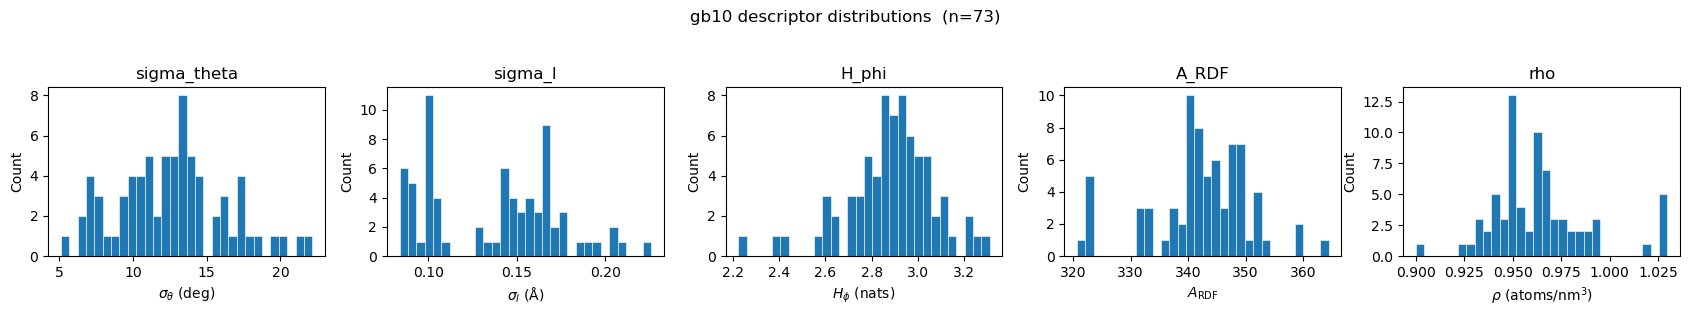

In [2]:
# Display rho in atoms/nm^3 (stored as atoms/Å^3; 1 nm^3 = 1000 Å^3).
# Local to this plot only -- df stays in Å^3 for PCA / ML.
rho_col = f"{SUBSET}_rho"
DISPLAY_SCALE  = {rho_col: 1e3}
DISPLAY_LABELS = {**DESC_LABELS, rho_col: r"$\rho$ (atoms/nm$^3$)"}

present = [c for c in DESC_COLS if c in df.columns]
fig, axes = plt.subplots(1, len(present), figsize=(3.4 * len(present), 3))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, present):
    vals = df[col].dropna() * DISPLAY_SCALE.get(col, 1.0)
    ax.hist(vals, bins=min(30, max(5, len(vals))), edgecolor="white", linewidth=0.4)
    ax.set_xlabel(DISPLAY_LABELS.get(col, col))
    ax.set_ylabel("Count")
    ax.set_title(col.replace(f"{SUBSET}_", ""))
fig.suptitle(f"{SUBSET} descriptor distributions  (n={len(df)})", y=1.04)
fig.tight_layout()
plt.show()

## 2. PCA of the disorder measures, colored by GB character

Standardize the five gb10 descriptors and project onto the first two principal
components. Points are colored by twist/tilt character (primary), with a
sigma-colored panel for context. The loading matrix shows which descriptors
drive each PC.

Explained variance ratio: [0.619 0.33 ]

Loadings:
               PC1    PC2
sigma_theta  0.515  0.304
sigma_l      0.533  0.160
H_phi        0.482  0.316
A_RDF        0.389 -0.559
rho         -0.257  0.685


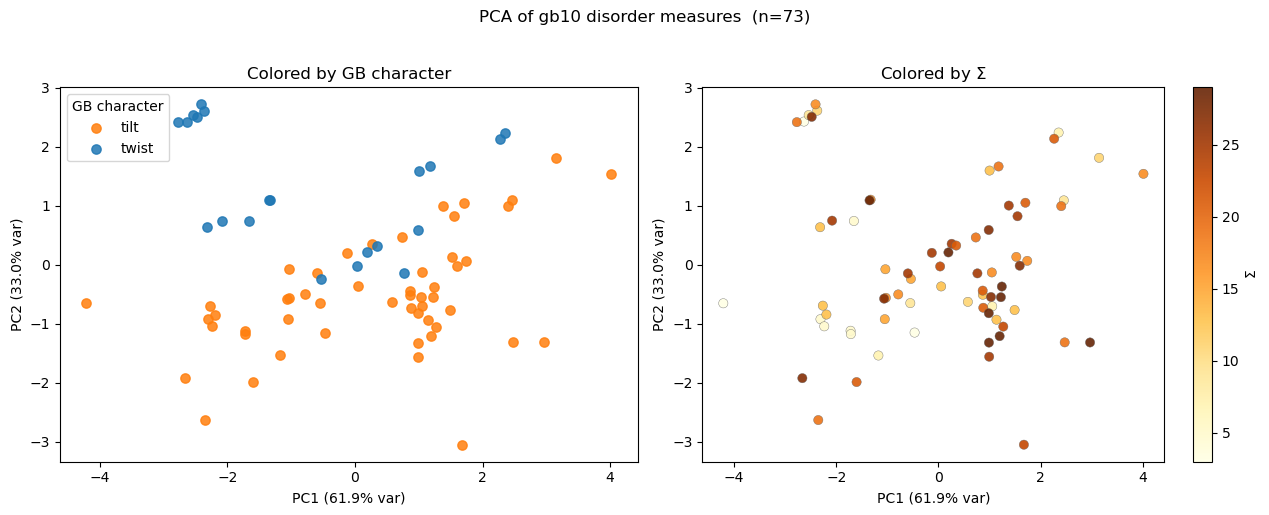

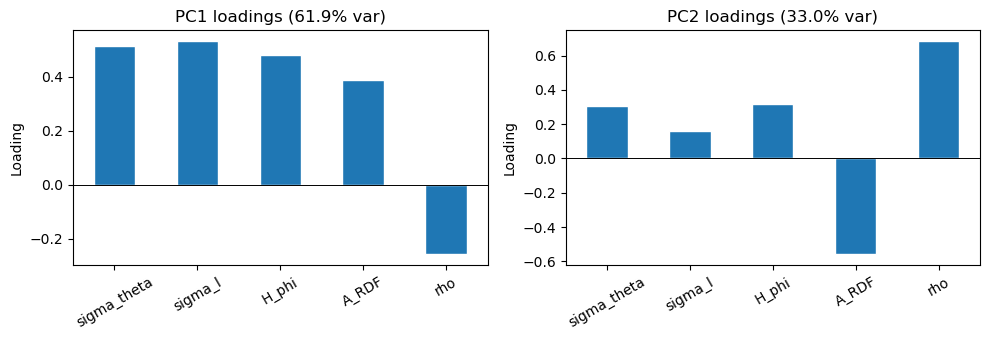

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_mask = df[DESC_COLS].notna().all(axis=1)
X_desc = df.loc[pca_mask, DESC_COLS].values
chars  = df.loc[pca_mask, "gb_character"].values
sigmas = df.loc[pca_mask, "sigma"].values

if len(X_desc) < 3:
    print(f"Only {len(X_desc)} rows with complete descriptors (need >=3). Skipping PCA.")
else:
    X_scaled = StandardScaler().fit_transform(X_desc)
    pca = PCA(n_components=2).fit(X_scaled)
    X_pca = pca.transform(X_scaled)
    evr = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=[c.replace(f"{SUBSET}_", "") for c in DESC_COLS],
        columns=["PC1", "PC2"],
    )
    print("Explained variance ratio:", np.round(evr, 3))
    print("\nLoadings:\n" + loadings.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ch in pd.unique(chars):
        m = chars == ch
        axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=45, alpha=0.85,
                        color=CHAR_COLORS.get(ch, "gray"), label=ch)
    axes[0].legend(title="GB character")
    axes[0].set_title("Colored by GB character")
    sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=sigmas, cmap="YlOrBr",
                         s=45, alpha=0.9, edgecolor="0.4", linewidth=0.3)
    plt.colorbar(sc, ax=axes[1], label="$\\Sigma$")
    axes[1].set_title("Colored by $\\Sigma$")
    for ax in axes:
        ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)")
        ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
    fig.suptitle(f"PCA of {SUBSET} disorder measures  (n={len(X_pca)})", y=1.02)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, pc in zip(axes, ["PC1", "PC2"]):
        loadings[pc].plot(kind="bar", ax=ax, edgecolor="white")
        ax.axhline(0, color="k", linewidth=0.7)
        ax.set_title(f"{pc} loadings ({evr[int(pc[-1]) - 1]:.1%} var)")
        ax.set_ylabel("Loading")
        ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

## 4. GB energy vs thermal boundary resistance

Relationship between the relaxed GB formation energy `gamma_j_m2` ($\gamma$) and
the Kapitza resistance `R_K_mean`. Error bars use the per-GB std columns where
available.

In [4]:
ev = df[df["gamma_j_m2"].notna() & df[TARGET].notna()]
if len(ev) == 0:
    print("GB energy (gamma_j_m2) not yet computed for any row with a target --"
          " skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)")
else:
    x = ev["gamma_j_m2"].to_numpy()
    y = ev[TARGET].to_numpy()
    yerr = ev["R_K_std"].to_numpy() if "R_K_std" in ev else None

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for ch in pd.unique(ev["gb_character"]):
        m = (ev["gb_character"] == ch).to_numpy()
        ax.errorbar(x[m], y[m], yerr=None if yerr is None else yerr[m],
                    fmt="o", ms=6, alpha=0.85, capsize=2,
                    color=CHAR_COLORS.get(ch, "gray"), label=ch)
    ax.set_xlabel(r"$\gamma$ (J/m$^2$)"); ax.set_ylabel(TARGET_LABEL)
    ax.set_title("GB energy vs TBR")
    ax.legend(title="GB character")
    fig.tight_layout()
    plt.show()

    if len(ev) >= 3:
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        print(f"Pearson  r = {r_p:+.3f}  (p = {p_p:.3g})")
        print(f"Spearman rho = {r_s:+.3f}  (p = {p_s:.3g})")
    else:
        print(f"Only {len(ev)} points -- correlation not meaningful.")

GB energy (gamma_j_m2) not yet computed for any row with a target -- skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)


## 5. Misorientation angle vs R_K

Misorientation is fixed per (axis, $\Sigma$) and sets the lattice mismatch
across the boundary. Here we check whether it tracks `R_K` on its own
(Spearman, monotonic). Inclination is dropped — it is NaN for twist/mixed and
~0 for symmetric tilt, so it covers only a third of the target rows and carries
little signal.

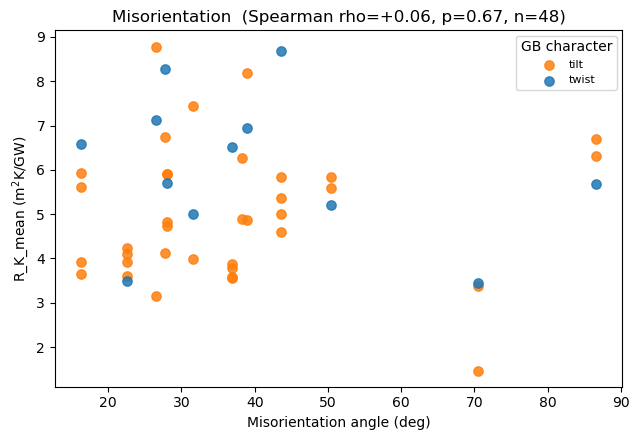

In [5]:
angle_col, title = "misorientation_deg", "Misorientation"
sub = df[df[angle_col].notna() & df[TARGET].notna()]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
if len(sub) == 0:
    ax.text(0.5, 0.5, f"No data for {angle_col}", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title(title)
else:
    for ch in pd.unique(sub["gb_character"]):
        m = sub["gb_character"] == ch
        ax.scatter(sub.loc[m, angle_col], sub.loc[m, TARGET], s=45, alpha=0.85,
                   color=CHAR_COLORS.get(ch, "gray"), label=ch)
    ax.set_xlabel(f"{title} angle (deg)"); ax.set_ylabel(TARGET_LABEL)
    ax.legend(title="GB character", fontsize=8)
    if sub[angle_col].nunique() >= 3 and len(sub) >= 3:
        r_s, p_s = stats.spearmanr(sub[angle_col], sub[TARGET])
        ax.set_title(f"{title}  (Spearman rho={r_s:+.2f}, p={p_s:.2g}, n={len(sub)})")
    else:
        ax.set_title(f"{title}  (n={len(sub)}, {sub[angle_col].nunique()} unique x)")
fig.tight_layout()
plt.show()

## 5b. Linear vs quadratic regression on the 2D PCA coordinates

Section 2 projects the five gb10 scalars onto two principal components. Here we
keep that **linear** PCA(2) embedding and ask whether `R_K` is better explained
by a **linear** or a **quadratic** model in those two coordinates:

- **linear** — $R_K \sim \mathrm{PC1} + \mathrm{PC2}$
- **quadratic** — $R_K \sim \mathrm{PC1} + \mathrm{PC2} + \mathrm{PC1}^2 +
  \mathrm{PC2}^2 + \mathrm{PC1}\,\mathrm{PC2}$  (squares + interaction)

Both are ridge-regularized linear regressions (`RidgeCV` picks $\alpha$ per
fold) on the **same** two coordinates — only the feature set differs, so any gap
is genuine curvature, not a different learner. The PCA and the polynomial
expansion live inside the pipeline, refit per CV fold (no leakage); a 5-scalar
linear ridge is the reference. The first figure shows the data in PC space and
the fitted quadratic response surface; the learning curve then compares
out-of-sample $R^2$.

PCA-coord regression: 48 GBs, 5 scalars -> 2 PCs
PCA(2) explains 94.7% of the 5-scalar variance (PC1 64.2%, PC2 30.5%)


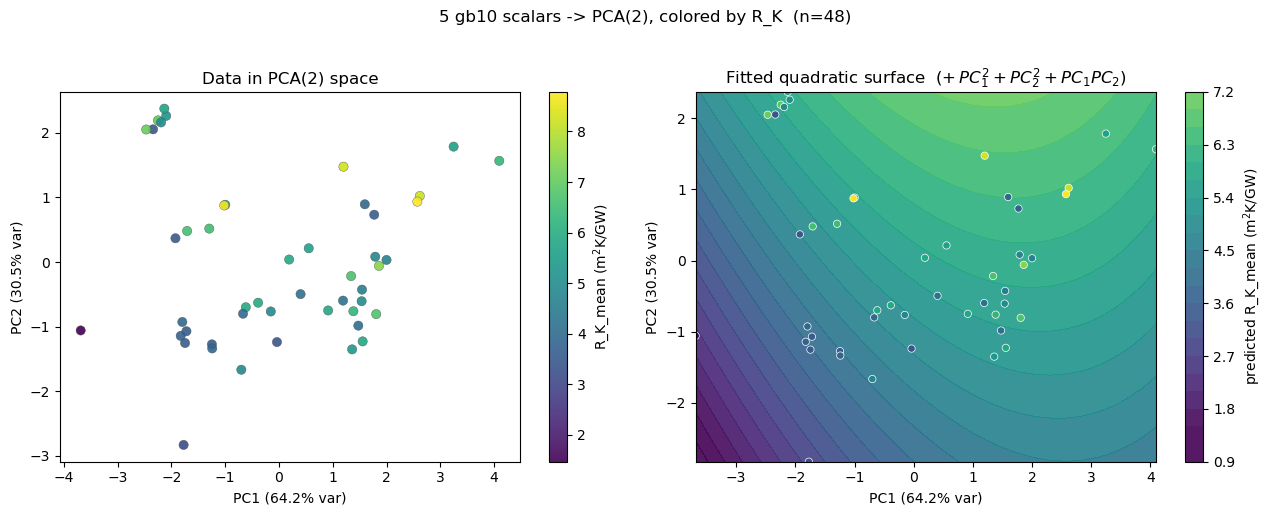

  5 scalars (linear)   R2 @ full = +0.045
  PC1,PC2 (linear)     R2 @ full = -0.039
  PC1,PC2 (quadratic)  R2 @ full = +0.021


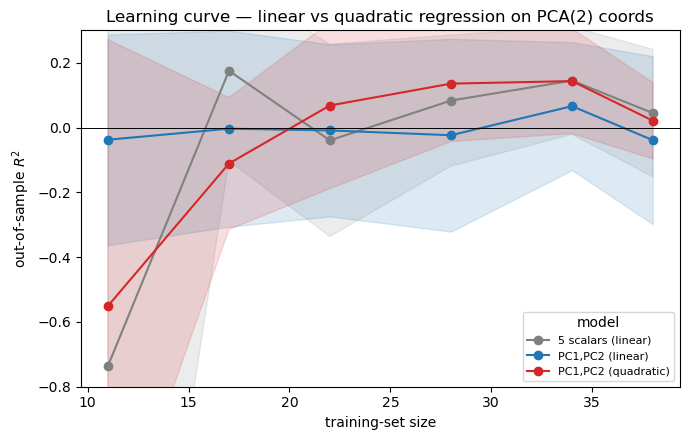

In [6]:
# Linear PCA(2) of the 5 gb10 scalars -> coordinates (PC1, PC2). Then compare a
# LINEAR vs a QUADRATIC regression MODEL on those two coordinates:
#   linear     R_K ~ PC1 + PC2
#   quadratic  R_K ~ PC1 + PC2 + PC1^2 + PC2^2 + PC1*PC2
# Same RidgeCV estimator throughout, so any gap is curvature -- not the learner.
# PCA + poly sit INSIDE the pipeline so both are refit per CV fold (no leakage).
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, learning_curve

emb_mask = df[DESC_COLS].notna().all(axis=1) & df[TARGET].notna()
Xs = df.loc[emb_mask, DESC_COLS].to_numpy()
ye = df.loc[emb_mask, TARGET].to_numpy()
print(f"PCA-coord regression: {emb_mask.sum()} GBs, {len(DESC_COLS)} scalars -> 2 PCs")

ALPHAS = np.logspace(-3, 3, 13)  # RidgeCV grid, per-fold leave-one-out alpha

# --- linear PCA(2) embedding (fit on all rows, for the scatter + surface) -----
emb = Pipeline([("sc", StandardScaler()),
                ("pca", PCA(n_components=2, random_state=RANDOM_STATE))])
Z = emb.fit_transform(Xs)
evr = emb.named_steps["pca"].explained_variance_ratio_
print(f"PCA(2) explains {evr.sum():.1%} of the 5-scalar variance "
      f"(PC1 {evr[0]:.1%}, PC2 {evr[1]:.1%})")

# Fit the quadratic model on all data once, purely to draw its response surface.
quad_all = Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                     ("m", RidgeCV(alphas=ALPHAS))]).fit(Z, ye)
gx, gy = np.meshgrid(np.linspace(Z[:, 0].min(), Z[:, 0].max(), 150),
                     np.linspace(Z[:, 1].min(), Z[:, 1].max(), 150))
gp = quad_all.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
vmin, vmax = ye.min(), ye.max()

# --- (a) data in PC space and the fitted quadratic surface --------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=ye, cmap="viridis", vmin=vmin, vmax=vmax,
                      s=45, alpha=0.9, edgecolor="0.3", linewidth=0.3)
fig.colorbar(sc0, ax=axes[0], label=TARGET_LABEL)
axes[0].set_title("Data in PCA(2) space")
cf = axes[1].contourf(gx, gy, gp, levels=20, cmap="viridis", vmin=vmin, vmax=vmax, alpha=0.9)
fig.colorbar(cf, ax=axes[1], label=f"predicted {TARGET_LABEL}")
axes[1].scatter(Z[:, 0], Z[:, 1], c=ye, cmap="viridis", vmin=vmin, vmax=vmax,
                s=28, edgecolor="white", linewidth=0.5)
axes[1].set_title(r"Fitted quadratic surface  ($+\,PC_1^2+PC_2^2+PC_1 PC_2$)")
for ax in axes:
    ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
fig.suptitle(f"5 gb10 scalars -> PCA(2), colored by R_K  (n={len(Z)})", y=1.02)
fig.tight_layout()
plt.show()

# --- (b) learning curves: linear vs quadratic model on the PCs (+5-scalar ref) -
models = {
    "5 scalars (linear)":  Pipeline([("sc", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
    "PC1,PC2 (linear)":    Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
    "PC1,PC2 (quadratic)": Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("poly", PolynomialFeatures(2, include_bias=False)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
}
colors = {"5 scalars (linear)": "0.5", "PC1,PC2 (linear)": "#1f77b4",
          "PC1,PC2 (quadratic)": "#d62728"}
sizes = np.array([0.3, 0.45, 0.6, 0.75, 0.9, 1.0])

fig, ax = plt.subplots(figsize=(7, 4.5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, pipe in models.items():
        ts, _, te = learning_curve(
            pipe, Xs, ye, train_sizes=sizes, scoring="r2", shuffle=True,
            random_state=RANDOM_STATE,
            cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))
        ax.plot(ts, te.mean(1), "o-", color=colors[name], label=name)
        ax.fill_between(ts, te.mean(1) - te.std(1), te.mean(1) + te.std(1),
                        color=colors[name], alpha=0.15)
        print(f"  {name:20s} R2 @ full = {te.mean(1)[-1]:+.3f}")
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("training-set size"); ax.set_ylabel("out-of-sample $R^2$")
ax.set_ylim(-0.8, 0.3)  # models overfit below ~20 GBs; clip the small-N dip
ax.set_title("Learning curve — linear vs quadratic regression on PCA(2) coords")
ax.legend(fontsize=8, title="model")
fig.tight_layout()
plt.show()

## 6. Descriptor–R_K pairplot

Pairwise relationships among the five gb10 disorder descriptors and the target
`R_K_mean`, colored by twist/tilt character. The diagonal shows each variable's
distribution; the **bottom row / right column** isolate each descriptor's
relationship to the thermal boundary resistance. ($\rho$ is shown in
atoms/nm³ to match section 1.)

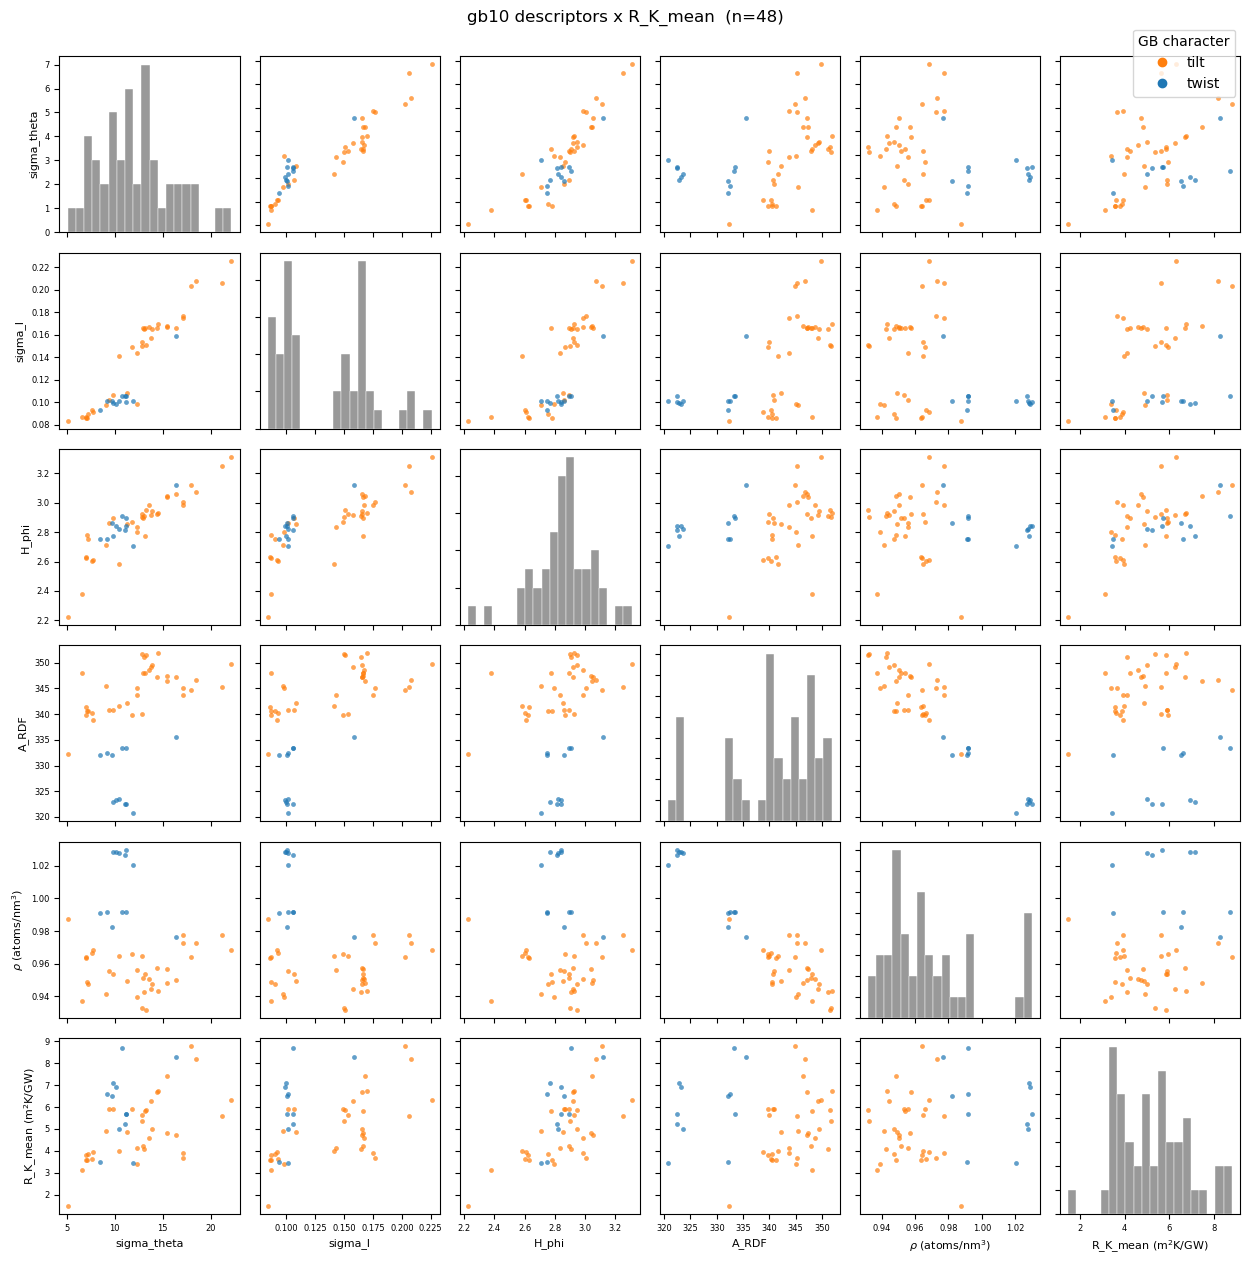

In [7]:
# Pairwise scatter matrix of the gb10 descriptors and R_K, colored by GB character.
# Diagonal = each variable's distribution; bottom row / right column = descriptor vs R_K.
pair_cols = DESC_COLS + [TARGET]
pp = df.dropna(subset=pair_cols)

if len(pp) < 3:
    print(f"Only {len(pp)} rows with all descriptors + {TARGET}; skipping pairplot.")
else:
    # rho shown in atoms/nm^3 (x1000) to match the section-1 distributions.
    PAIR_SCALE  = {f"{SUBSET}_rho": 1e3}
    PAIR_LABELS = {c: c.replace(f"{SUBSET}_", "") for c in DESC_COLS}
    PAIR_LABELS[f"{SUBSET}_rho"] = r"$\rho$ (atoms/nm$^3$)"
    PAIR_LABELS[TARGET] = TARGET_LABEL

    n = len(pair_cols)
    data  = {c: pp[c].to_numpy() * PAIR_SCALE.get(c, 1.0) for c in pair_cols}
    chars = pp["gb_character"].to_numpy()

    fig, axes = plt.subplots(n, n, figsize=(2.1 * n, 2.1 * n))
    for i, ci in enumerate(pair_cols):
        for j, cj in enumerate(pair_cols):
            ax = axes[i, j]
            if i == j:
                ax.hist(data[ci], bins=min(20, max(5, len(pp))),
                        color="0.6", edgecolor="white", linewidth=0.3)
            else:
                for ch in pd.unique(chars):
                    m = chars == ch
                    ax.scatter(data[cj][m], data[ci][m], s=12, alpha=0.7,
                               color=CHAR_COLORS.get(ch, "gray"), linewidth=0)
            ax.tick_params(labelsize=6)
            ax.set_xlabel(PAIR_LABELS[cj], fontsize=8) if i == n - 1 else ax.set_xticklabels([])
            ax.set_ylabel(PAIR_LABELS[ci], fontsize=8) if j == 0 else ax.set_yticklabels([])

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
                          color=CHAR_COLORS.get(ch, "gray"), label=ch)
               for ch in pd.unique(chars)]
    fig.legend(handles=handles, title="GB character",
               loc="upper right", bbox_to_anchor=(0.99, 0.99))
    fig.suptitle(f"{SUBSET} descriptors x {TARGET}  (n={len(pp)})", y=1.0)
    fig.tight_layout()
    plt.show()

## 7. Predicting R_K — multi-model regression with nested CV

With only ~50 grain boundaries, a single held-out test set is too noisy. We
estimate out-of-sample error with **nested cross-validation**:

- **Outer loop** — shuffled `KFold`. Each outer fold yields a genuine
  out-of-sample score.
- **Inner loop** — `GridSearchCV` tunes each model's hyperparameters using only
  the outer-training data (no leakage).

Models: Ridge, KNN, RandomForest, XGBoost, a **Ridge+KNN averaging ensemble**
(best out-of-sample RMSE in our tests — a linear + a local learner whose errors
partly cancel), and a mean baseline. Features are the five gb10 disorder
measures **plus two macroscopic-geometry features** (misorientation angle and
$\Sigma$), which give the distance/linear models a small but real edge. Target
is `R_K_mean`.

> Two transforms we tried and dropped (no gain once predictions were scored
> back in raw m²K/GW space): a **log-transformed target** (the raw target is
> already roughly symmetric) and adding the **`full`-subset descriptors** (they
> are collinear with the gb10 ones and inflated variance). See section 9 for
> which features actually carry signal.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Five gb10 disorder measures + two macroscopic-geometry features. Geometry is
# fully populated on the target rows (no rows lost) and helps the linear/local
# models; see section 9 for the per-feature importance.
GEOM_FEATURES = ["misorientation_deg", "sigma"]
FEATURES = list(DESC_COLS) + GEOM_FEATURES

mldf = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
X = mldf[FEATURES].to_numpy()
y = mldf[TARGET].to_numpy()
print(f"Modeling on {len(mldf)} GBs, {len(FEATURES)} features, target = {TARGET}")

N_OUTER = 5


def build_models():
    '''name -> (pipeline, param_grid). Scaler is harmless for trees, needed for
    Ridge / KNN / the ensemble.'''
    return {
        "Ridge": (
            Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
            {"m__alpha": [1e-3, 1e-2, 1e-1, 1, 10, 100]},
        ),
        "KNN": (
            Pipeline([("sc", StandardScaler()), ("m", KNeighborsRegressor())]),
            {"m__n_neighbors": [3, 5, 7, 9], "m__weights": ["uniform", "distance"]},
        ),
        "RandomForest": (
            Pipeline([("sc", StandardScaler()),
                      ("m", RandomForestRegressor(random_state=RANDOM_STATE))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [None, 3, 5],
             "m__max_features": ["sqrt", 1.0]},
        ),
        "XGBoost": (
            Pipeline([("sc", StandardScaler()),
                      ("m", XGBRegressor(random_state=RANDOM_STATE, n_jobs=1,
                                         objective="reg:squarederror"))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [2, 3],
             "m__learning_rate": [0.03, 0.1], "m__subsample": [0.8, 1.0]},
        ),
        # Average a linear (Ridge) and a local (KNN) learner: their errors are
        # partly independent, so the mean has lower variance -- best
        # out-of-sample RMSE on this small, noisy dataset.
        "Ridge+KNN": (
            Pipeline([("sc", StandardScaler()),
                      ("m", VotingRegressor([("ridge", Ridge()),
                                             ("knn", KNeighborsRegressor())]))]),
            {"m__ridge__alpha": [0.1, 1, 10],
             "m__knn__n_neighbors": [5, 7, 9],
             "m__knn__weights": ["uniform", "distance"]},
        ),
        "Baseline (mean)": (
            Pipeline([("m", DummyRegressor(strategy="mean"))]),
            {},
        ),
    }


def nested_cv(y_target, target_label=""):
    '''Nested CV for an arbitrary target vector, reusing the global feature
    matrix X and mldf. Outer = shuffled KFold (no stratification); inner =
    KFold grid search. Returns (results_df, oof_pred): results_df is the
    per-model score table; oof_pred maps each model name -> a length-n vector of
    out-of-fold predictions (each GB predicted by the fold that held it out),
    used for the section-8 parity plots. Returns (None, None) if too few rows.'''
    if len(mldf) < 2 * N_OUTER:
        print(f"Only {len(mldf)} usable rows (< {2 * N_OUTER}); skipping CV.\n"
              "Re-run once dataset.csv is more complete.")
        return None, None

    print(f"Outer CV: KFold(n_splits={N_OUTER}, shuffle=True)"
          + (f"  |  target = {target_label}" if target_label else "") + "\n")

    outer = KFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    inner = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    rows = []
    oof_pred = {name: np.full(len(y_target), np.nan) for name in build_models()}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # silence fit-time convergence chatter
        for name, (pipe, grid) in build_models().items():
            f_rmse, f_mae, f_r2 = [], [], []
            for tr, te in outer.split(X):
                if grid:
                    search = GridSearchCV(pipe, grid, cv=inner,
                                          scoring="neg_root_mean_squared_error",
                                          n_jobs=N_JOBS)
                    search.fit(X[tr], y_target[tr])
                    est = search.best_estimator_
                else:
                    est = pipe.fit(X[tr], y_target[tr])
                pred = est.predict(X[te])
                oof_pred[name][te] = pred
                f_rmse.append(np.sqrt(mean_squared_error(y_target[te], pred)))
                f_mae.append(mean_absolute_error(y_target[te], pred))
                f_r2.append(r2_score(y_target[te], pred))
            rows.append({
                "model": name,
                "RMSE_mean": np.mean(f_rmse), "RMSE_std": np.std(f_rmse),
                "MAE_mean": np.mean(f_mae),   "MAE_std": np.std(f_mae),
                "R2_mean": np.mean(f_r2),     "R2_std": np.std(f_r2),
            })
            print(f"  {name:16s} RMSE={np.mean(f_rmse):.3e} +/- {np.std(f_rmse):.1e}   "
                  f"R2={np.mean(f_r2):+.3f}")

    return pd.DataFrame(rows).set_index("model"), oof_pred

Modeling on 48 GBs, 7 features, target = R_K_mean


In [9]:
cv_results, oof_pred = nested_cv(y, target_label=f"{TARGET} ({TBR_UNIT})")

if cv_results is not None:
    print("\n=== Nested-CV out-of-sample performance ===")
    print(cv_results.round(4).to_string())

Outer CV: KFold(n_splits=5, shuffle=True)  |  target = R_K_mean (m$^2$K/GW)

  Ridge            RMSE=1.376e+00 +/- 2.2e-01   R2=+0.087
  KNN              RMSE=1.346e+00 +/- 2.5e-01   R2=+0.125
  RandomForest     RMSE=1.459e+00 +/- 1.8e-01   R2=-0.074
  XGBoost          RMSE=1.506e+00 +/- 1.9e-01   R2=-0.142
  Ridge+KNN        RMSE=1.378e+00 +/- 2.8e-01   R2=+0.096
  Baseline (mean)  RMSE=1.571e+00 +/- 3.4e-01   R2=-0.166

=== Nested-CV out-of-sample performance ===
                 RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean  R2_std
model                                                                   
Ridge               1.3760    0.2170    1.1533   0.2060   0.0870  0.1047
KNN                 1.3460    0.2526    1.1198   0.2404   0.1248  0.1881
RandomForest        1.4590    0.1848    1.1840   0.2083  -0.0737  0.2720
XGBoost             1.5059    0.1937    1.1674   0.2154  -0.1420  0.3414
Ridge+KNN           1.3779    0.2775    1.1413   0.2452   0.0961  0.1469
Baseline (mean)    

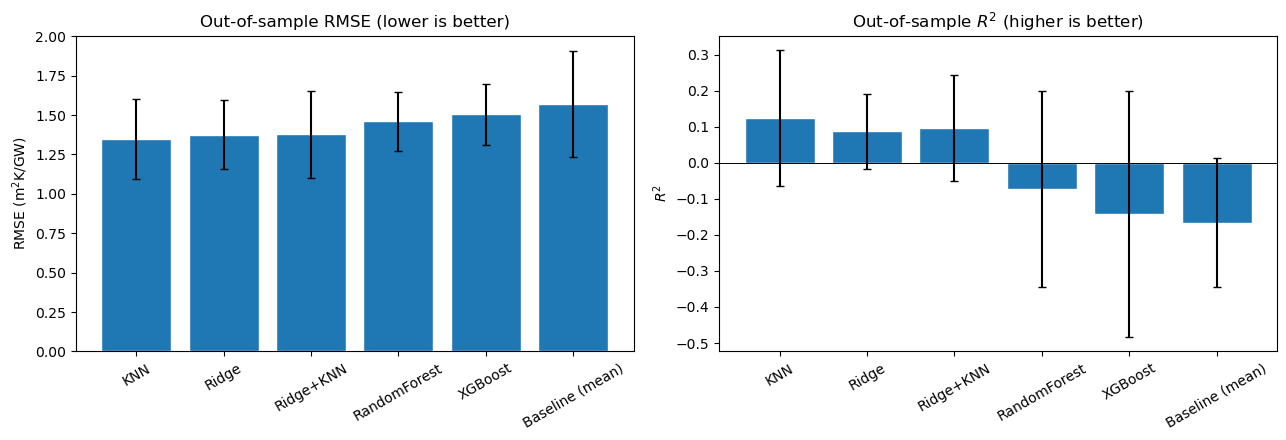

In [10]:
if cv_results is None:
    print("No CV results to plot.")
else:
    order = cv_results["RMSE_mean"].sort_values().index
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(order, cv_results.loc[order, "RMSE_mean"],
                yerr=cv_results.loc[order, "RMSE_std"], capsize=3, edgecolor="white")
    axes[0].set_ylabel(f"RMSE ({TBR_UNIT})")
    axes[0].set_title("Out-of-sample RMSE (lower is better)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[1].bar(order, cv_results.loc[order, "R2_mean"],
                yerr=cv_results.loc[order, "R2_std"], capsize=3, edgecolor="white")
    axes[1].axhline(0, color="k", linewidth=0.7)
    axes[1].set_ylabel("$R^2$"); axes[1].set_title("Out-of-sample $R^2$ (higher is better)")
    axes[1].tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

## 8. Parity plots — predicted vs measured R_K (out-of-fold)

Each panel pools the **out-of-fold** predictions from the nested-CV outer loop:
every GB is predicted by the fold in which it was held out, so nothing is
in-sample. The dashed line is the 1:1 ideal; the grey band is ±1 RMSE. $R^2$
and RMSE annotate each model, and points are colored by GB character. With ~50
GBs and weak structural signal these clouds are wide — the parity view exposes
the spread, any systematic over/under-prediction, and which GBs are outliers
far better than a single $R^2$ number does.

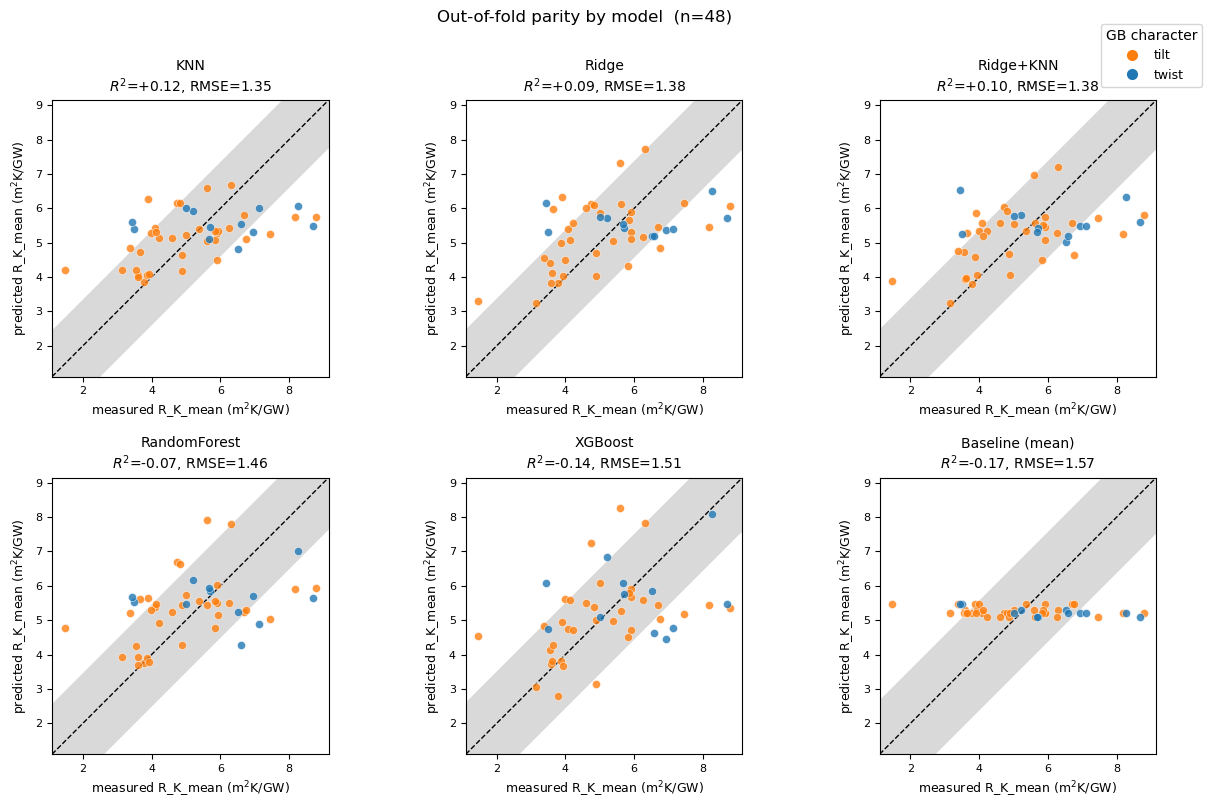

In [11]:
if cv_results is None:
    print("No CV results to plot.")
else:
    # One parity panel per model, ordered best-RMSE first.
    order = cv_results["RMSE_mean"].sort_values().index.tolist()
    chars = mldf["gb_character"].to_numpy()

    lo = min(y.min(), min(np.nanmin(oof_pred[m]) for m in order))
    hi = max(y.max(), max(np.nanmax(oof_pred[m]) for m in order))
    pad = 0.05 * (hi - lo)
    lo, hi = lo - pad, hi + pad

    ncols = 3
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows),
                             squeeze=False)
    for ax, name in zip(axes.ravel(), order):
        pred = oof_pred[name]
        rmse = cv_results.loc[name, "RMSE_mean"]
        r2   = cv_results.loc[name, "R2_mean"]
        # +/-1 RMSE band around the 1:1 line
        ax.fill_between([lo, hi], [lo - rmse, hi - rmse], [lo + rmse, hi + rmse],
                        color="0.85", zorder=0)
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        for ch in pd.unique(chars):
            m = chars == ch
            ax.scatter(y[m], pred[m], s=34, alpha=0.8, zorder=2,
                       color=CHAR_COLORS.get(ch, "gray"), edgecolor="white",
                       linewidth=0.4, label=ch)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        ax.set_xlabel(f"measured {TARGET_LABEL}", fontsize=9)
        ax.set_ylabel(f"predicted {TARGET_LABEL}", fontsize=9)
        ax.set_title(f"{name}\n$R^2$={r2:+.2f}, RMSE={rmse:.2f}", fontsize=10)
        ax.tick_params(labelsize=8)

    for ax in axes.ravel()[len(order):]:
        ax.axis("off")

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                          color=CHAR_COLORS.get(ch, "gray"), label=ch)
               for ch in pd.unique(chars)]
    fig.legend(handles=handles, title="GB character", loc="upper right",
               bbox_to_anchor=(0.995, 0.995), fontsize=9)
    fig.suptitle(f"Out-of-fold parity by model  (n={len(y)})", y=1.005)
    fig.tight_layout()
    plt.show()

## 10. How much is even predictable? — noise floor & learning curve

Before chasing a better model, two diagnostics that bound what is achievable:

- **Noise-floor ceiling.** `R_K_mean` is the average over 5 rNEMD replicas;
  `R_K_std` is their spread, so each GB's label has standard error
  $R\_K\_std/\sqrt{5}$. The fraction of the between-GB variance that is *not*
  replica noise is the ceiling on any model's $R^2$. It comes out **≈ 0.97** —
  the labels are precise, so almost all of the variance is, in principle,
  learnable.
- **Learning curve.** Out-of-sample $R^2$ vs training-set size for the best
  (Ridge+KNN) model. It climbs to ~0.2 by ~30 GBs and then **flattens**: with
  the current features, more data buys little, and we sit *far* below the 0.97
  ceiling. The gap is **missing descriptor signal**, not noise and not (mostly)
  sample size.

Between-GB variance of R_K_mean:        2.537 (m$^2$K/GW)^2
Mean replica-noise variance of the mean: 0.0653
=> predictable-variance ceiling:  R^2 <= 0.974
   best model so far reaches R^2 ~ +0.12  ->  most learnable signal is still on the table.


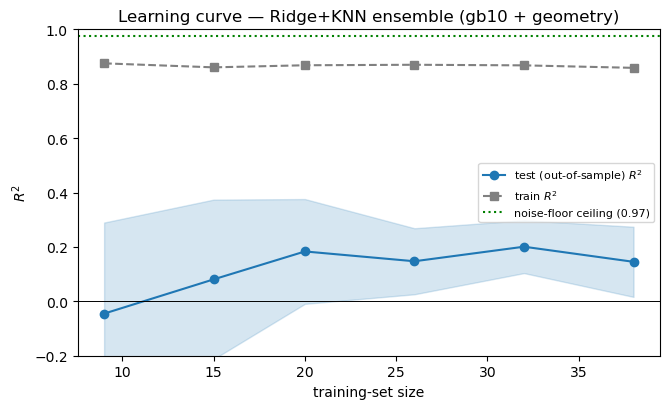

In [12]:
# (a) Predictable-variance ceiling from rNEMD replica noise, and
# (b) a learning curve for the best (ensemble) model.
from sklearn.model_selection import learning_curve

if cv_results is None:
    print("No CV results -- skipping diagnostics.")
else:
    # --- (a) noise-floor ceiling -------------------------------------------
    # R_K_mean averages N_REPLICAS rNEMD runs; R_K_std (already in m^2K/GW) is
    # their spread, so SE of the mean = R_K_std / sqrt(N_REPLICAS). Label-noise
    # variance = mean(SE^2); ceiling R^2 = 1 - mean(SE^2)/var(R_K_mean).
    N_REPLICAS = 5
    tgt = df[df[TARGET].notna()]
    ceiling = None
    if "R_K_std" in df.columns and tgt["R_K_std"].notna().any():
        se2 = (tgt["R_K_std"] ** 2 / N_REPLICAS).mean()
        var_between = tgt[TARGET].var(ddof=1)
        ceiling = 1.0 - se2 / var_between
        print(f"Between-GB variance of {TARGET}:        {var_between:.3f} ({TBR_UNIT})^2")
        print(f"Mean replica-noise variance of the mean: {se2:.4f}")
        print(f"=> predictable-variance ceiling:  R^2 <= {ceiling:.3f}")
        print(f"   best model so far reaches R^2 ~ {cv_results['R2_mean'].max():+.2f}"
              f"  ->  most learnable signal is still on the table.")
    else:
        print("R_K_std unavailable; skipping noise-floor estimate.")

    # --- (b) learning curve -------------------------------------------------
    lc_pipe = Pipeline([("sc", StandardScaler()),
                        ("m", VotingRegressor([
                            ("ridge", Ridge(alpha=10)),
                            ("knn", KNeighborsRegressor(n_neighbors=7,
                                                        weights="distance"))]))])
    sizes = np.array([0.25, 0.4, 0.55, 0.7, 0.85, 1.0])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ts, tr_sc, te_sc = learning_curve(
            lc_pipe, X, y, train_sizes=sizes, scoring="r2", shuffle=True,
            random_state=RANDOM_STATE,
            cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    ax.plot(ts, te_sc.mean(1), "o-", color="#1f77b4", label="test (out-of-sample) $R^2$")
    ax.fill_between(ts, te_sc.mean(1) - te_sc.std(1), te_sc.mean(1) + te_sc.std(1),
                    color="#1f77b4", alpha=0.18)
    ax.plot(ts, tr_sc.mean(1), "s--", color="0.5", label="train $R^2$")
    if ceiling is not None:
        ax.axhline(ceiling, color="green", ls=":",
                   label=f"noise-floor ceiling ({ceiling:.2f})")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel("training-set size")
    ax.set_ylabel("$R^2$")
    ax.set_ylim(-0.2, 1.0)
    ax.set_title("Learning curve — Ridge+KNN ensemble (gb10 + geometry)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

## 11. Coordination-defect descriptors — the first real lift

The disorder *scalars* and SOAP all plateau near $R^2\approx0.2$ (section 10). A
physically sharper descriptor finally moves the needle: **coordination
defects**. Silicon is tetrahedral, so the fraction of under-/over-coordinated
atoms in the 10 Å GB slab — plus the mean/std of the coordination number —
directly counts the broken/strained bonding that scatters phonons.

These four `gb10_coord_*` features are computed by
`ml/compute_coordination.py` (cached to `ml/gb10_coordination.csv`) and are now
also emitted by `format_cleaned_data.py` for future dataset builds. Adding them
lifts the best out-of-sample $R^2$ by ~0.1 — e.g. KNN $0.13\!\to\!0.28$ here,
and $0.22\!\to\!0.30$ under repeated-seed pooled-OOF — **robust across CV seeds,
and the first descriptor change in this pipeline that beats the disorder
scalars.** (SOAP, by contrast, did not help: mean/anomaly pooling is diluted by
the bulk-like atoms that dominate the slab.)

Loaded ml/gb10_coordination.csv: coordination present for 48/48 modeled GBs

### scalars (gb10+geom)  (p=7)
           RMSE_mean  R2_mean
Ridge         1.3760   0.0870
KNN           1.3460   0.1248
Ridge+KNN     1.3779   0.0961

### coordination only  (p=4)
           RMSE_mean  R2_mean
Ridge         1.4217   0.0151
KNN           1.2324   0.2751
Ridge+KNN     1.2741   0.2168

### scalars + coordination  (p=11)
           RMSE_mean  R2_mean
Ridge         1.3116   0.1847
KNN           1.3260   0.1567
Ridge+KNN     1.2978   0.2011

Best: KNN on 'coordination only'  ->  R2=+0.275


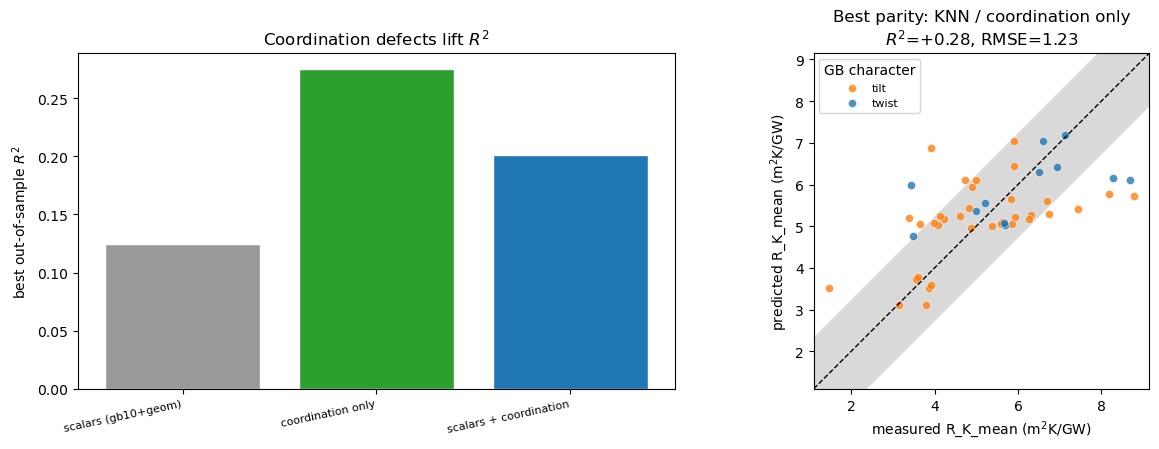

In [13]:
# Coordination-defect lift: compare scalars / coordination / both under the
# same nested CV as section 7. Reads the ml/compute_coordination.py cache.
import os

COORD_COLS = [f"{SUBSET}_coord_{s}" for s in ("under", "over", "mean", "std")]
_cache_candidates = ["ml/gb10_coordination.csv", "gb10_coordination.csv",
                     os.path.join(os.path.dirname(DATASET), "gb10_coordination.csv")]
COORD_CACHE = next((p for p in _cache_candidates if os.path.exists(p)), None)

if cv_results is None:
    print("No base CV results; skipping coordination comparison.")
elif COORD_CACHE is None:
    print("Coordination cache not found. Generate it with:")
    print("    python ml/compute_coordination.py")
    print(f"(looked in: {_cache_candidates})")
else:
    coord_df = pd.read_csv(COORD_CACHE)
    mc = mldf.merge(coord_df, on="gb_label", how="left")
    ok = mc[COORD_COLS].notna().all(axis=1).to_numpy()
    print(f"Loaded {COORD_CACHE}: coordination present for {ok.sum()}/{len(mc)} modeled GBs")

    yc = mc.loc[ok, TARGET].to_numpy()
    feat_sets = {
        "scalars (gb10+geom)":    mc.loc[ok, FEATURES].to_numpy(),
        "coordination only":      mc.loc[ok, COORD_COLS].to_numpy(),
        "scalars + coordination": mc.loc[ok, FEATURES + COORD_COLS].to_numpy(),
    }
    cmp_models = {k: build_models()[k] for k in ("Ridge", "KNN", "Ridge+KNN")}

    def coord_cv(Xmat):
        outer = KFold(N_OUTER, shuffle=True, random_state=RANDOM_STATE)
        inner = KFold(3, shuffle=True, random_state=RANDOM_STATE)
        res, oof = {}, {}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for name, (pipe, grid) in cmp_models.items():
                pred = np.full(len(yc), np.nan); rms = []; r2 = []
                for tr, te in outer.split(Xmat):
                    srch = GridSearchCV(pipe, grid, cv=inner,
                                        scoring="neg_root_mean_squared_error",
                                        n_jobs=N_JOBS)
                    srch.fit(Xmat[tr], yc[tr]); est = srch.best_estimator_
                    p = est.predict(Xmat[te]); pred[te] = p
                    rms.append(np.sqrt(mean_squared_error(yc[te], p)))
                    r2.append(r2_score(yc[te], p))
                res[name] = {"RMSE_mean": np.mean(rms), "R2_mean": np.mean(r2)}
                oof[name] = pred
        return pd.DataFrame(res).T, oof

    tables, oofs = {}, {}
    for label, Xm in feat_sets.items():
        tables[label], oofs[label] = coord_cv(Xm)
        print(f"\n### {label}  (p={Xm.shape[1]})")
        print(tables[label].round(4).to_string())

    bfs, bm = max(((fs, m) for fs in tables for m in tables[fs].index),
                  key=lambda km: tables[km[0]].loc[km[1], "R2_mean"])
    print(f"\nBest: {bm} on '{bfs}'  ->  R2={tables[bfs].loc[bm,'R2_mean']:+.3f}")

    # (a) best-R2 per feature set; (b) parity for the best combo
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    fs_names = list(feat_sets)
    best_r2 = [tables[fs]["R2_mean"].max() for fs in fs_names]
    axes[0].bar(range(len(fs_names)), best_r2,
                color=["0.6", "#2ca02c", "#1f77b4"], edgecolor="white")
    axes[0].set_xticks(range(len(fs_names)))
    axes[0].set_xticklabels(fs_names, rotation=12, ha="right", fontsize=8)
    axes[0].axhline(0, color="k", lw=0.7)
    axes[0].set_ylabel("best out-of-sample $R^2$")
    axes[0].set_title("Coordination defects lift $R^2$")

    pr = oofs[bfs][bm]; rmse = tables[bfs].loc[bm, "RMSE_mean"]
    lo = min(yc.min(), np.nanmin(pr)); hi = max(yc.max(), np.nanmax(pr))
    pad = 0.05 * (hi - lo); lo, hi = lo - pad, hi + pad
    chars = mc.loc[ok, "gb_character"].to_numpy()
    ax = axes[1]
    ax.fill_between([lo, hi], [lo - rmse, hi - rmse], [lo + rmse, hi + rmse],
                    color="0.85", zorder=0)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    for ch in pd.unique(chars):
        m = chars == ch
        ax.scatter(yc[m], pr[m], s=34, alpha=0.8, color=CHAR_COLORS.get(ch, "gray"),
                   edgecolor="white", linewidth=0.4, label=ch)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel(f"measured {TARGET_LABEL}"); ax.set_ylabel(f"predicted {TARGET_LABEL}")
    ax.legend(title="GB character", fontsize=8)
    ax.set_title(f"Best parity: {bm} / {bfs}\n$R^2$={tables[bfs].loc[bm,'R2_mean']:+.2f}, "
                 f"RMSE={rmse:.2f}")
    fig.tight_layout(); plt.show()

## 12. Where the model stands & how to push it further

**Progress so far**, in order of impact:
1. **Coordination-defect descriptors (section 11) — the first real lift.**
   Best out-of-sample $R^2$ rose from ~0.13/0.25 to ~0.28/0.30, robust across CV
   seeds. Physically sharp (broken tetrahedral bonding scatters phonons) and now
   wired into `format_cleaned_data.py`.
2. **Macroscopic geometry** (misorientation, $\Sigma$) + a **Ridge+KNN
   ensemble** (section 7).
3. **Honest diagnostics** (section 10): the noise-floor ceiling is
   $R^2\approx0.97$, so the labels are precise and most variance is still
   learnable — the gap is descriptor signal, not noise.

**Tested and ruled out** (don't repeat): SOAP (mean- and anomaly-pooled — the
bulk-like atoms that dominate the slab wash out the GB signal), a
log-transformed target, the `full`-subset descriptors, and every extra model
family (RF/XGB/SVR/GPR/PLS/ExtraTrees/GBR). Model choice is not the lever.

**Highest-leverage next steps:**

1. **Push the coordination thread — it's what's working.** Go beyond
   under/over fractions: **bond-orientational order** (Steinhardt $q_4,q_6$),
   **ring statistics**, or the full **per-atom coordination histogram**; and
   sweep the slab width / try the `full` subset. Cheap and aligned with the one
   idea that beat the scalars.
2. **Physics descriptors — phonon-DOS mismatch** across the interface from the
   NEP potential (VACF from a short MD run; a 100k-atom Hessian is infeasible
   directly). Highest ceiling, most work.
3. **GB energy `gamma_j_m2`** once populated (all-NaN today) — physically tied
   to interfacial scattering.
4. **Breadth, not just count** — new $\Sigma$ values and rotation axes, scored
   with a **`GroupKFold` by $\Sigma$** for honest extrapolation (the section-10
   learning curve says raw sample count buys little).

> **Rebuild note.** `format_cleaned_data.py` now also emits `{subset}_coord_*`
> columns. To fold them into `dataset.csv`, rebuild from scratch (the resume path
> won't backfill columns into existing rows). Until then the notebook reads the
> `ml/gb10_coordination.csv` cache, regenerated by `python ml/compute_coordination.py`.